In [6]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

data = pd.read_csv("../../data/preprocessed/preprocessed_dataset.csv")

X = data.drop(columns=["class", "subject", "expression"])
y = data["expression"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

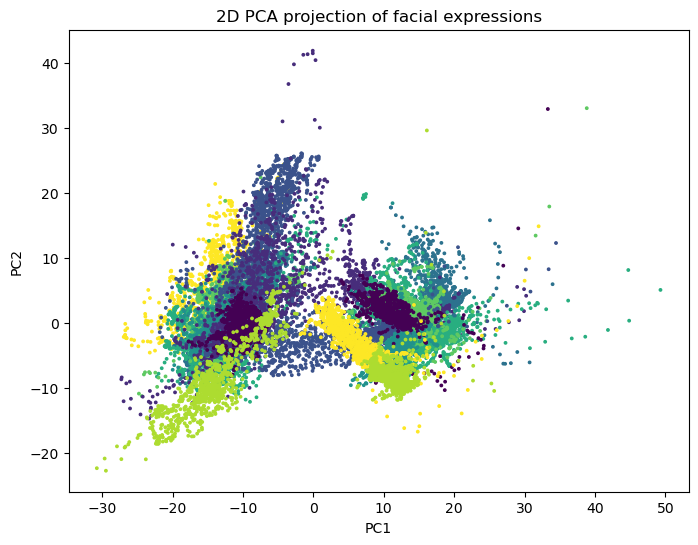

In [ ]:
# 2D PCA vizuelizacija
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(
    X_pca2[:,0],
    X_pca2[:,1],
    c=data["expression"].astype("category").cat.codes,
    s=3
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("2D PCA projection of facial expressions")
plt.show()

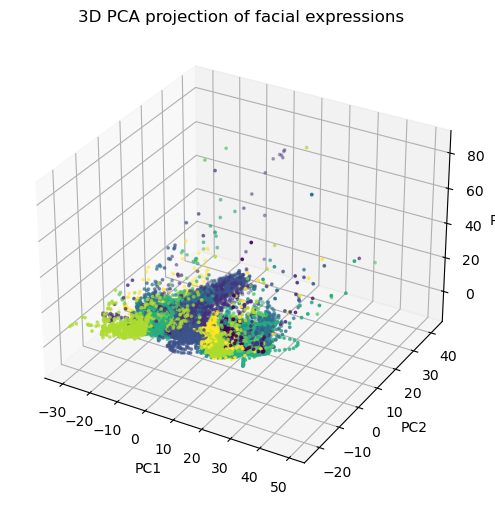

In [11]:
# 3D PCA vizuelizacija
pca3 = PCA(n_components=3)
X_pca3 = pca3.fit_transform(X_scaled)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca3[:,0],
    X_pca3[:,1],
    X_pca3[:,2],
    c=data["expression"].astype("category").cat.codes,
    s=3
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

plt.title("3D PCA projection of facial expressions")
plt.show()

In [13]:
X_pca = PCA(n_components=0.95)
X_pca = X_pca.fit_transform(X_scaled)

# Čuvanje rezultata u .npy formatu jer su manji, brže se učitavaju i efikasniji su za rad sa modelima 
# bez potrebe za ponovnim skaliranjem ili PCA transformacijom, tj. bez parsiranja CSV fajla i ponovnog izvođenja svih koraka preprocesiranja.
np.save("../../data/reduced/X_scaled.npy", X_scaled)
np.save("../../data/reduced/X_pca.npy", X_pca)